In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Normalmente representamos um arranjo em python usando listas

a=[1,2,3,4,5]

for i in range (len(a)):
  a[i]=a[i]*2
print(a)

[2, 4, 6, 8, 10]


In [ ]:
# Em numpy, as operações são vetores, portanto podem ser executadas em tempo constante

a=np.array([1,2,3,4,5])
print(a*3)

[ 3  6  9 12 15]


In [ ]:
# Em arranjos bidimensionais, a vetorização é ainda mais poderosa

A=np.array([[1,2,3],[4,5,6],[7,8,9]])

print(A)


[[1 2 3]
 [4 5 6]
 [7 8 9]]


In [ ]:
print(np.average(A,axis=1)) #Média por linha

[2. 5. 8.]


In [ ]:
I=np.eye(3) #Matriz identidade
print(I)


[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [ ]:
print(np.dot(A,I)) #Multiplicação de matrizes

[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]


In [ ]:
print(A.T) #Matriz transposta

[[1 4 7]
 [2 5 8]
 [3 6 9]]


## Regressão logística




$h(x)=\sigma(x \cdot w +b)$ onde:

$\sigma(z)= \frac {1}{1+e^{-z}}$

In [ ]:
def sigmoide(z):
  return 1/(1+np.exp(-z))

In [ ]:
def logistic_regression(x,w,b):
  return sigmoide(np.dot(x,w)+b)

In [ ]:
def gradients(X, Y, Y_hat):
    n = X.shape[0]
    dw = np.dot(X.T, (Y_hat - Y)) / n   # (2,30) x (30,1) = (2,1)
    db = np.sum(Y_hat - Y) / n          # escalar
    return dw, db

In [ ]:
def binary_cross_entropy(Y, Y_hat, eps=1e-15):
    Y_hat = np.clip(Y_hat, eps, 1 - eps)
    n = Y.shape[0]
    loss = -np.mean(Y * np.log(Y_hat) + (1 - Y) * np.log(1 - Y_hat))
    return loss

In [ ]:
def predict(X, w, b, threshold=0.5, return_proba=False):
    probas = logistic_regression(X, w, b)
    Y_pred = (probas >= threshold).astype(float)
    if return_proba:
        return Y_pred, probas
    return Y_pred

In [ ]:
def accuracy(Y_true, Y_pred):
    """Calcula a acurácia comparando rótulos verdadeiros e previstos."""
    return np.mean(Y_true == Y_pred)

In [ ]:
def gradient_descent(X, Y, epochs=10000, learning_rate=0.1, plot=True):
    """Treina uma regressão logística via gradiente descendente.

    Retorna w, b e o histórico de perdas. A plotagem é opcional
    (parâmetro plot) para não acoplar treino e visualização.
    """
    d = X.shape[1]
    # inicializar os pesos w e b
    w = np.random.rand(d, 1)
    b = 0.0
    losses = []
    for i in range(epochs):
        # Previsão com a regressão logística
        Y_hat = logistic_regression(X, w, b)
        # Calcular os gradientes
        dw, db = gradients(X, Y, Y_hat)
        # Atualizar os pesos
        w -= learning_rate * dw
        b -= learning_rate * db
        loss = binary_cross_entropy(Y, Y_hat)
        losses.append(loss)

    if plot:
        plt.plot(losses)
        plt.xlabel('Época')
        plt.ylabel('Perda (BCE)')
        plt.title('Curva de perda durante o treinamento')
        plt.show()

    return w, b, losses


In [ ]:
# Seed fixa para reprodutibilidade dos resultados
np.random.seed(42)

# Gerando os dados

n_alunos=30
mean=7
std=2

X=np.random.normal(loc=mean,scale=std,size=(n_alunos,2))
X=np.clip(X,0,10)
print(X)

[[ 7.99342831  6.7234714 ]
 [ 8.29537708 10.        ]
 [ 6.53169325  6.53172609]
 [10.          8.53486946]
 [ 6.06105123  8.08512009]
 [ 6.07316461  6.06854049]
 [ 7.48392454  3.17343951]
 [ 3.55016433  5.87542494]
 [ 4.97433776  7.62849467]
 [ 5.18395185  4.1753926 ]
 [ 9.93129754  6.5484474 ]
 [ 7.13505641  4.15050363]
 [ 5.91123455  7.22184518]
 [ 4.69801285  7.75139604]
 [ 5.79872262  6.4166125 ]
 [ 5.79658678 10.        ]
 [ 6.97300555  4.88457814]
 [ 8.64508982  4.5583127 ]
 [ 7.41772719  3.08065975]
 [ 4.3436279   7.39372247]
 [ 8.47693316  7.34273656]
 [ 6.76870344  6.39779261]
 [ 4.04295602  5.56031158]
 [ 6.07872246  9.11424445]
 [ 7.68723658  3.47391969]
 [ 7.64816794  6.22983544]
 [ 5.646156    8.22335258]
 [ 9.06199904  8.86256024]
 [ 5.32156495  6.38157525]
 [ 7.66252686  8.95109025]]


In [ ]:
# definindo os rótulos

Y=(np.average(X,axis=1)>=mean)+0.0

Y = Y.reshape(-1, 1)
Y.shape

(30, 1)

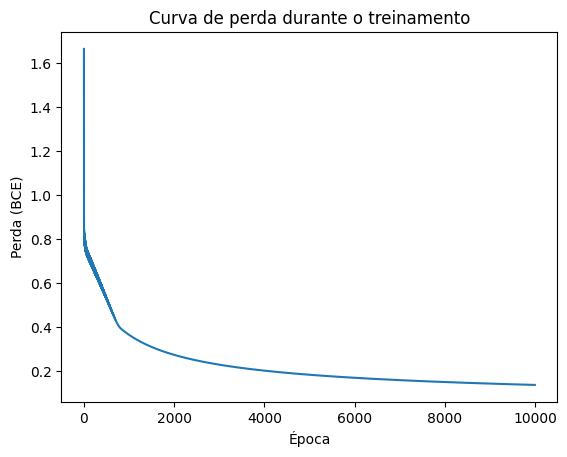

In [ ]:
# Chamando a função do gradiente descendente

w,b,losses=gradient_descent(X,Y,epochs=10000,learning_rate=0.1)

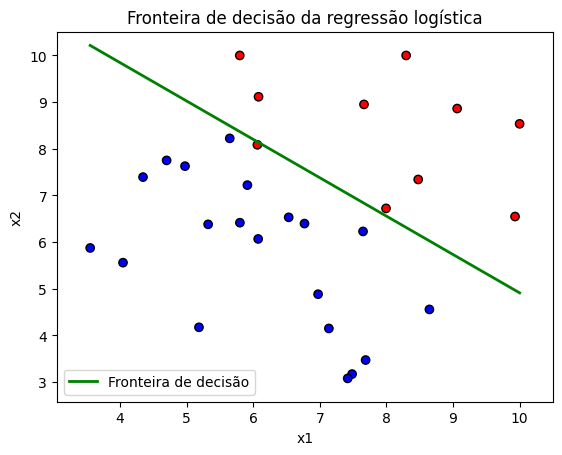

In [ ]:
x1_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
x2_vals = -(w[0,0] * x1_vals + b) / w[1,0]

plt.scatter(X[:,0], X[:,1], c=Y.ravel(), cmap='bwr', edgecolors='k')
plt.plot(x1_vals, x2_vals, 'g-', linewidth=2, label='Fronteira de decisão')
plt.xlim(X[:,0].min() - 0.5, X[:,0].max() + 0.5)
plt.ylim(X[:,1].min() - 0.5, X[:,1].max() + 0.5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.title('Fronteira de decisão da regressão logística')
plt.show()

## Vetor gradiente (derivadas parciais) de função de perda entropia cruzada binária em relação aos pesos w e b para um exemplo $x_i$.

$ \frac{\partial L}{\partial w} = (\hat{y}^{(i)}-y^{(i)}).x^{(i)}$

$ \frac{\partial L}{\partial b} = (\hat{y}^{(i)}-y^{(i)})$

## Derivadas em relação ao conjunto de dados completo X, sem vetorização.

$\frac{\partial L}{\partial w}=\frac{1}{n}\displaystyle\sum_{i=1}^{n}(\hat{y}^{(i)}-y^{(i)}).x^{(i)}$

$\frac{\partial L}{\partial b}=\frac{1}{n}\displaystyle\sum_{i=1}^{n}(\hat{y}^{(i)}-y^{(i)})$

## Derivadas em relação ao conjunto de dados completo X, com vetorização.

$\frac{\partial L}{\partial w}=\frac{1}{n}X^T.(\hat{Y}-Y)$

$\frac{\partial L}{\partial b}=\frac{1}{n}\displaystyle\sum_{i=1}^{n}(\hat{y}^{(i)}-y^{(i)})$




In [ ]:
# Fazendo previsões com o modelo

novas_notas=[[7,8],[5,6],[6,5],[8,9]]

novas_notas=np.array(novas_notas)


Y_true=(np.average(novas_notas,axis=1)>=mean)+0.0
Y_true=Y_true.reshape(-1,1)

Y_predict=predict(novas_notas,w,b)






In [ ]:
# Acurácia do modelo

acc=accuracy(Y_true,Y_predict)
print(acc)

1.0
